## **Credit Scoring Model using Machine Learning**

**Objective**:
To predict whether a customer is creditworthy or not using Machine Learning classification algorithms.

# Workflow

1. Import Libraries
2. Load Dataset
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Engineering
6. Data Preprocessing
7. Model Training
8. Model Evaluation
9. Prediction System
10. Conclusion

**Algorithms used:**


*   Logistic Regression
*   Decision Tree
*   Random Forest

**Evaluation Metrics:**

*   Accuracy
*   Pression
*   Recall
*   F1-Score
*   ROC-AUC





In [83]:
#Importing Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [84]:
#Uploading Dataset

from google.colab import files

uploaded = files.upload()

Saving german_credit_data.csv to german_credit_data (1).csv


In [85]:
#Loading Dataset

df = pd.read_csv('german_credit_data.csv')

In [86]:
df.drop('Unnamed: 0', axis=1, inplace=True)


np.random.seed(42)

df['Risk'] = np.where(
    (
        (
            (df['Credit amount'] > 5000) &
            (df['Duration'] > 24)
        )
        |
        (df['Age'] < 25)
    ),
    1,
    0
)

# Add small randomness
random_noise = np.random.choice(
    [0,1],
    size=len(df),
    p=[0.92, 0.08]
)

df['Risk'] = abs(df['Risk'] - random_noise)

In [87]:
#Dataset Information

print("Dataset Shape:", df.shape)

print("\nDataset Information:\n")

df.info()

Dataset Shape: (1000, 10)

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [88]:
#Checking Missing Values

df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [89]:
#Handling missing values

df.fillna(method='ffill', inplace=True)

print("Missing Values Handled Successfully")

Missing Values Handled Successfully


In [90]:
#Statistical Summary

df.describe()

,Age,Job,Credit amount,Duration,Risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000,0.301000
std,11.375469,0.653614,2822.736876,12.058814,0.458922
min,19.000000,0.000000,250.000000,4.000000,0.000000
25%,27.000000,2.000000,1365.500000,12.000000,0.000000
50%,33.000000,2.000000,2319.500000,18.000000,0.000000
75%,42.000000,2.000000,3972.250000,24.000000,1.000000
max,75.000000,3.000000,18424.000000,72.000000,1.000000


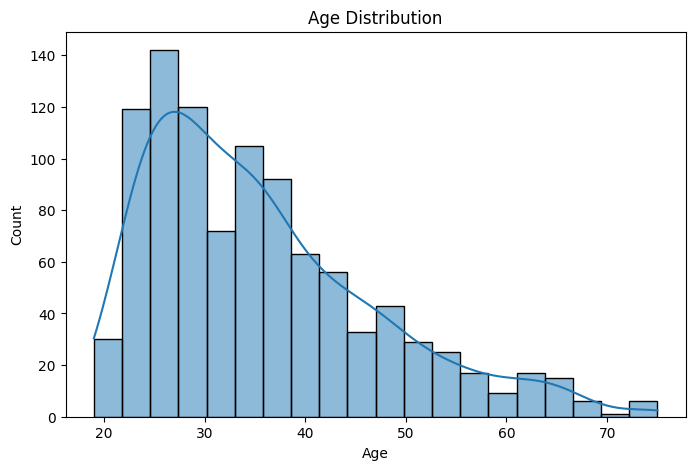

In [91]:
#Age Distribution Graph

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

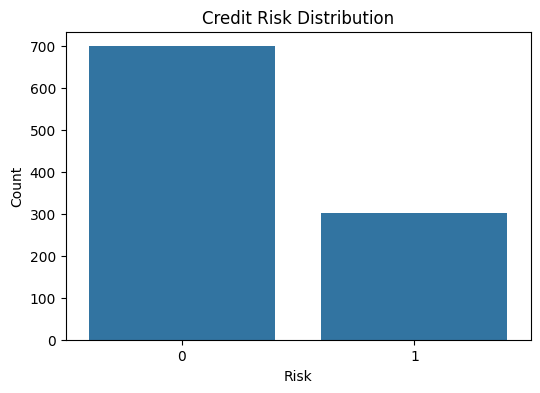

In [92]:
#Credit risk visualization

plt.figure(figsize=(6,4))

sns.countplot(x='Risk', data=df)

plt.title("Credit Risk Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")

plt.show()

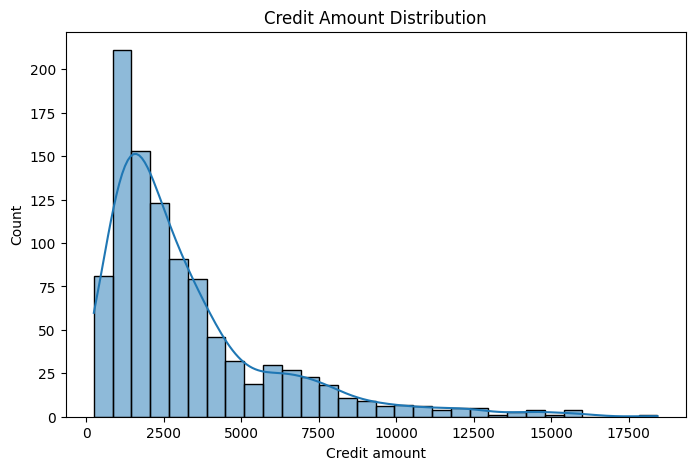

In [93]:
#Credit Amount distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Credit amount'], bins=30, kde=True)

plt.title("Credit Amount Distribution")

plt.show()

In [94]:
#Encode Categorical Columns

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

print("Categorical Data Encoded Successfully")

Categorical Data Encoded Successfully


In [95]:
#Feature Engineering

df['Debt_to_Age'] = df['Credit amount'] / (df['Age'] + 1)

df['Income_Per_Duration'] = df['Credit amount'] / (df['Duration'] + 1)

print("Feature Engineering Completed")

Feature Engineering Completed


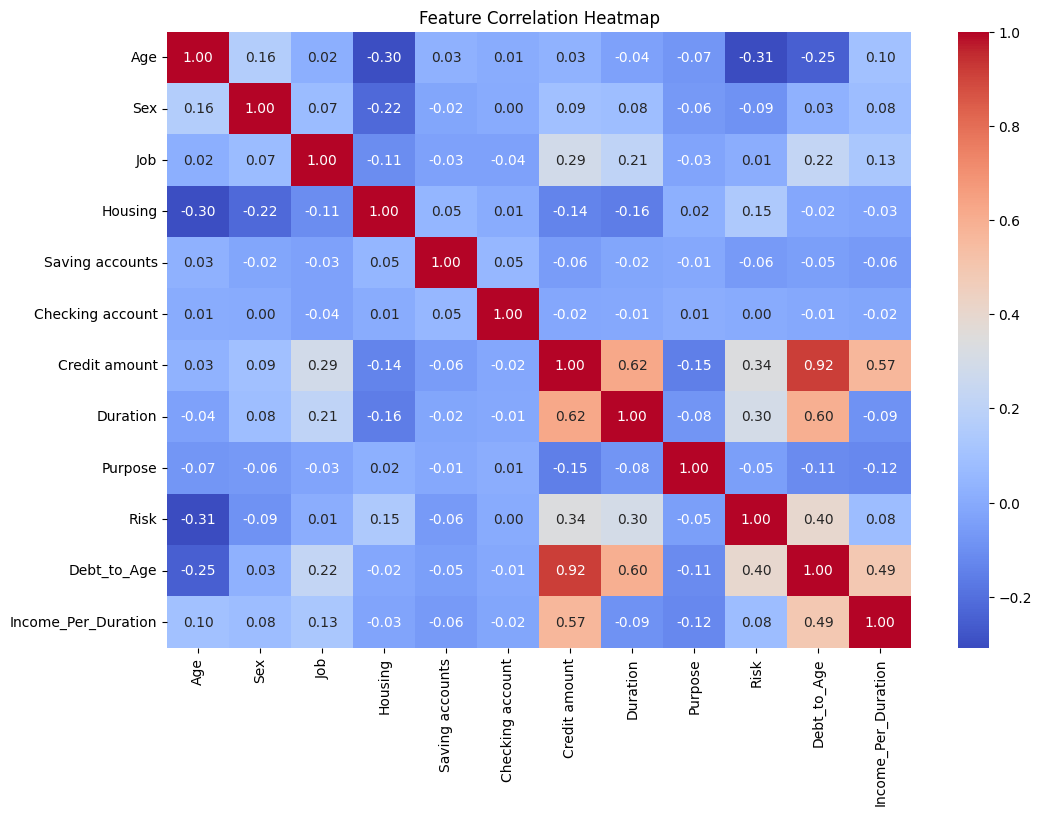

In [96]:
#Correlation Heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [97]:
#Defining Features and Target

X = df.drop('Risk', axis=1)

y = df['Risk']

print("Features and Target Created")

Features and Target Created


In [98]:
#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Completed")

Train-Test Split Completed


In [99]:
#Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [100]:
#Logistic Regression Model

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy: {:.2f}%".format(lr_accuracy * 100))

Logistic Regression Accuracy: 81.00%


In [101]:
#Decision Tree model

dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy: {:.2f}%".format(dt_accuracy * 100))

Decision Tree Accuracy: 86.50%


In [102]:
#Random Forest Model

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy: {:.2f}%".format(rf_accuracy * 100))

Random Forest Accuracy: 92.50%


In [103]:
#Model Comparison table

comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

# Convert accuracy into percentage
comparison_df['Accuracy'] = comparison_df['Accuracy'] * 100

comparison_df

,Model,Accuracy
0,Logistic Regression,81.0
1,Decision Tree,86.5
2,Random Forest,92.5


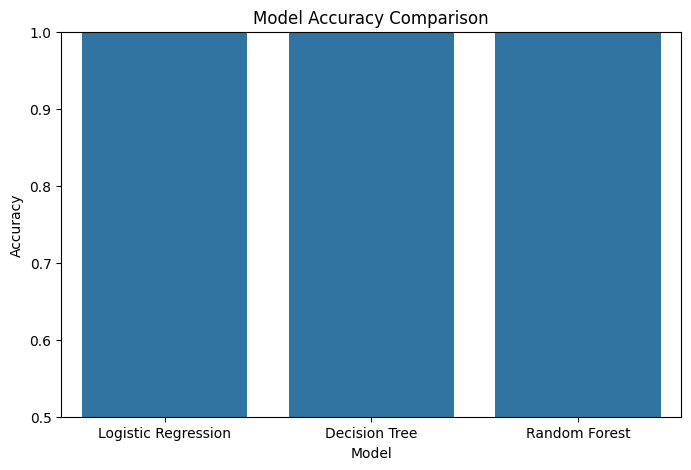

In [104]:
#Model Comparison Graph

plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Model Accuracy Comparison")

plt.ylim(0.5,1.0)

plt.show()

In [105]:
#Classification Report

print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.92      0.98      0.95       140
           1       0.94      0.80      0.86        60

    accuracy                           0.93       200
   macro avg       0.93      0.89      0.91       200
weighted avg       0.93      0.93      0.92       200



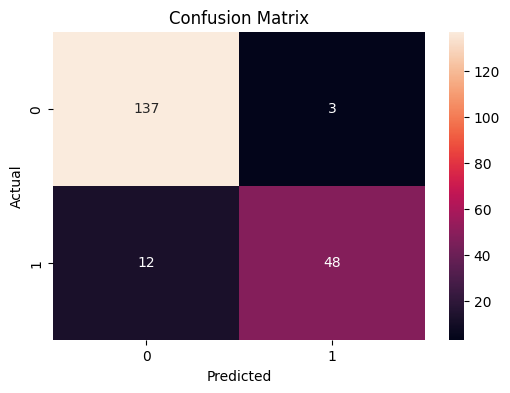

In [106]:
#Confusion Matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [107]:
#ROC AUC Score

rf_prob = rf.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, rf_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9545238095238096


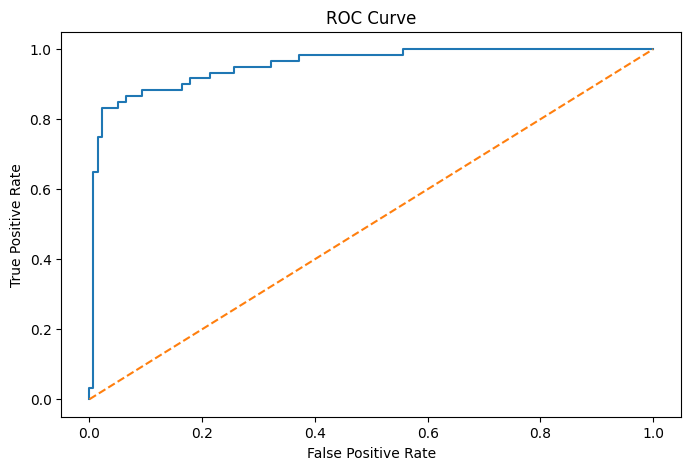

In [108]:
#ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

In [109]:
#Feature Importance

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Age,0.366032
6,Credit amount,0.169018
9,Debt_to_Age,0.166404
7,Duration,0.116381
10,Income_Per_Duration,0.088424
3,Housing,0.036567
2,Job,0.016133
8,Purpose,0.013984
4,Saving accounts,0.009998
1,Sex,0.009815


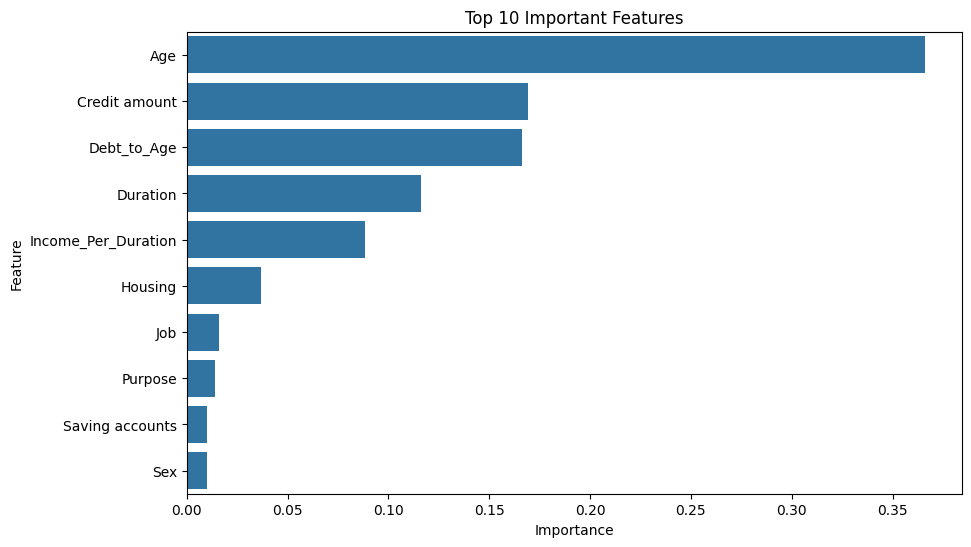

In [110]:
#Feature Importance graph

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [112]:
#Sample Prediction system

sample_customer = X.iloc[0:1]

sample_customer_scaled = scaler.transform(sample_customer)

prediction = rf.predict(sample_customer_scaled)

if prediction[0] == 1:
    print("Customer is Creditworthy")
else:
    print("Customer is NOT Creditworthy")

Customer is NOT Creditworthy


## Real World Applications

- Helps banks evaluate loan applicants.
- Reduces financial risk and loan defaults.
- Automates creditworthiness prediction.
- Supports faster and smarter financial decision-making.

# **Conclusion**
**The Smart Credit Scoring Model was successfully developed using Machine Learning Classification algorithms**.


**Among all the models used**:
- **Random Forest achieved the best Performance**.


**The Project successfully predicts customer creditworthiness using financial attributes and can help financial institutions reduce loan default risks**.
